# Estrategias Evolutivas (ES) y Evolución Diferencial (DE)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/05_estrategias_evolutivas_y_de.ipynb)

## Objetivos


- Comprender las limitaciones del Algoritmo Genético clásico en espacios continuos de alta dimensionalidad y alta epistasis (variables correlacionadas).
- Dominar las **Estrategias Evolutivas (ES)** y el concepto de *Autoadaptación* del tamaño de paso.
- Entender la intuición geométrica detrás de la **Evolución Diferencial (DE)** y por qué es invariante a la rotación y traslación.
- Realizar un análisis de sensibilidad empírico para los hiperparámetros de DE ($F$ y $CR$).
- Diagnosticar la "muerte clínica" de un algoritmo analizando su curva de diversidad en un benchmark de alta dificultad (Rosenbrock 20D).



## Prerrequisitos


- Haber completado: [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb).
- Familiaridad con funciones de benchmark y el Teorema *No Free Lunch*.

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

try:
    import deap
except ImportError:
    !pip install deap
from deap import base, creator, tools, algorithms

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 21.7 MB/s eta 0:00:00


## Introducción Teórica: Más allá del GA Clásico


El Algoritmo Genético (GA) que construimos en los primeros notebooks es una herramienta fantástica, pero tiene dos debilidades críticas cuando operamos en espacios continuos ($x \in \mathbb{R}^D$) de alta dimensionalidad:

1. **El tamaño de paso ($\sigma$) es fijo:** En nuestro GA, la mutación gaussiana usaba un $\sigma$ constante. La analogía sería exactamente la misma que usamos al incorporar el `lr` (*learning rate*) variable en el entrenamiento de redes profundas del capítulo anterior. Al inicio de todo, nos interesa que los pasos sean largos (así la convergencia se acelera), pero, al acercanos al objetivo, los pasos largos generan un rebote de un lado al otro, sin llegar al objetivo o punto exacto buscado. Un $\sigma$ fijo es siempre un compromiso subóptimo.
2. **El cruce ignora la geometría del paisaje:** Mezclar coordenadas de dos padres a veces destruye estructuras útiles, especialmente si las variables están correlacionadas.

Para resolver esto, la ingeniería evolutiva desarrolló dos paradigmas que dominan la optimización continua moderna: las **Estrategias Evolutivas (ES)** y la **Evolución Diferencial (DE)**.


## Parte I: Estrategias Evolutivas (ES) y la Autoadaptación



¿Qué pasaría si el algoritmo pudiera *aprender* qué tamaño de paso dar?

En las Estrategias Evolutivas, el cromosoma se **extiende**. Ya no solo contiene las variables del problema ($x$), sino que también incluye sus propios parámetros de mutación ($\sigma$).

$$ \text{Individuo} = [x_1, x_2, \dots, x_D, \sigma_1, \sigma_2, \dots, \sigma_D] $$

Durante la mutación, primero mutamos el $\sigma$ (haciéndolo más grande o más chico). Luego, usamos ese *nuevo* $\sigma$ para mutar la variable $x$.
*Si un individuo da un paso con un $\sigma$ pequeño y encuentra un fitness excelente, sobrevivirá, y transmitirá ese $\sigma$ pequeño a su descendencia.* ¡El algoritmo se autoadapta!



### 1. Nomenclatura Clásica


*   **$(\mu + \lambda)$-ES:** Los padres ($\mu$) generan hijos ($\lambda$). Luego, padres e hijos compiten juntos por sobrevivir. Garantiza elitismo estricto.
*   **$(\mu, \lambda)$-ES:** Los padres generan hijos, y luego *los padres mueren*. Solo los mejores hijos sobreviven.

> **Pregunta de Ingeniería:** ¿Por qué querríamos matar a los padres si tienen mejor fitness que los hijos?
> Porque en paisajes muy engañosos o dinámicos (donde el óptimo se mueve con el tiempo), aferrarse a un padre viejo causa estancamiento. La estrategia "coma" ($\mu, \lambda$) fuerza a la población a seguir moviéndose, sacrificando convergencia a corto plazo por mayor exploración a largo plazo.



### 2. Implementación en DEAP


Vamos a optimizar la función de **Ackley en 10 Dimensiones**.


In [2]:
DIMENSIONES = 10
BOUND_LOW, BOUND_UP = -32.0, 32.0

def ackley_10d(individuo):
    # IMPORTANTE: El individuo tiene 20 genes (10 de 'x' y 10 de 'sigma').
    # Solo evaluamos los primeros 10 genes.

    x = np.array(individuo[:DIMENSIONES])
    term1 = -20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / DIMENSIONES))
    term2 = -np.exp(np.sum(np.cos(2 * np.pi * x)) / DIMENSIONES)
    return (term1 + term2 + 20 + np.e,)

for cls in ['FitnessMin', 'Individual']:
    if hasattr(creator, cls): delattr(creator, cls)

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

tb_es = base.Toolbox()

# Generadores: Inicializamos 'x' en el dominio, y 'sigma' con un valor inicial (ej. 3.0)
def generar_individuo_es():
    x = [random.uniform(BOUND_LOW, BOUND_UP) for _ in range(DIMENSIONES)]
    sigmas = [random.uniform(1.0, 3.0) for _ in range(DIMENSIONES)]
    return creator.Individual(x + sigmas)

tb_es.register("individual", generar_individuo_es)
tb_es.register("population", tools.initRepeat, list, tb_es.individual)
tb_es.register("evaluate", ackley_10d)

# Operador de Mutación Autoadaptativa
def mutacion_autoadaptativa(individuo):
    tau = 1.0 / np.sqrt(2.0 * DIMENSIONES)
    tau_prime = 1.0 / np.sqrt(2.0 * np.sqrt(DIMENSIONES))
    ruido_global = random.gauss(0, 1)

    for i in range(DIMENSIONES):
        # 1. Mutamos el Sigma
        individuo[DIMENSIONES + i] *= np.exp(tau_prime * ruido_global + tau * random.gauss(0, 1))
        # Evitamos que sigma sea exactamente 0
        individuo[DIMENSIONES + i] = max(individuo[DIMENSIONES + i], 1e-5)

        # 2. Mutamos la X usando el nuevo Sigma
        individuo[i] += random.gauss(0, individuo[DIMENSIONES + i])
        # Clipping, para evitar salirnos del dominio establecido
        individuo[i] = max(BOUND_LOW, min(BOUND_UP, individuo[i]))

    return individuo,

tb_es.register("mutate", mutacion_autoadaptativa)
# En ES, el cruce suele ser discreto (intercambio de variables)
tb_es.register("mate", tools.cxTwoPoint)
tb_es.register("select", tools.selTournament, tournsize=3)

### 3. Ejecución: $(\mu + \lambda)$ vs $(\mu, \lambda)$


In [3]:
MU = 20      # Cantidad de padres
LAMBDA = 100 # Cantidad de hijos generados por generación
NGEN = 150

stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register("min", np.min)

# 1. Ejecución (Mu + Lambda)
pop_plus = tb_es.population(n=MU)
hof_plus = tools.HallOfFame(1)
pop_plus, log_plus = algorithms.eaMuPlusLambda(
    pop_plus, tb_es, mu=MU, lambda_=LAMBDA, cxpb=0.6, mutpb=0.3,
    ngen=NGEN, stats=stats, halloffame=hof_plus, verbose=False)

# 2. Ejecución (Mu , Lambda)
pop_comma = tb_es.population(n=MU)
hof_comma = tools.HallOfFame(1)
pop_comma, log_comma = algorithms.eaMuCommaLambda(
    pop_comma, tb_es, mu=MU, lambda_=LAMBDA, cxpb=0.6, mutpb=0.3,
    ngen=NGEN, stats=stats, halloffame=hof_comma, verbose=False)

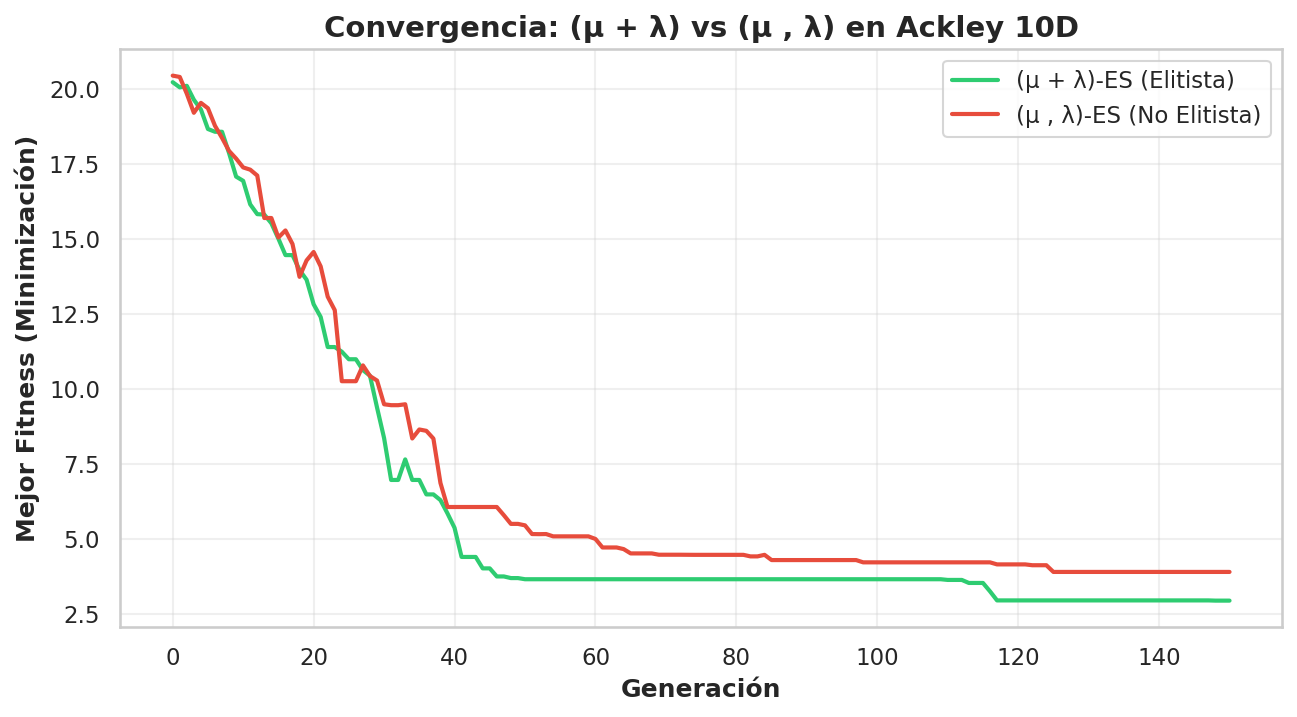

Mejor (μ + λ): 2.6527
Mejor (μ , λ): 3.9110


In [4]:
# Visualización
plt.figure(figsize=(10, 5))
plt.plot(log_plus.select("gen"), log_plus.select("min"), label='(μ + λ)-ES (Elitista)', color='#2ecc71', lw=2)
plt.plot(log_comma.select("gen"), log_comma.select("min"), label='(μ , λ)-ES (No Elitista)', color='#e74c3c', lw=2)
plt.title("Convergencia: (μ + λ) vs (μ , λ) en Ackley 10D")
plt.xlabel("Generación")
plt.ylabel("Mejor Fitness (Minimización)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mejor (μ + λ): {hof_plus[0].fitness.values[0]:.4f}")
print(f"Mejor (μ , λ): {hof_comma[0].fitness.values[0]:.4f}")

**Análisis de Resultados:**   
En nuestras pruebas, la estrategia $(\mu + \lambda)$ alcanzó un fitness de $\approx 2,65$, mientras que la estrategia "coma" $(\mu , \lambda)$ llegó a $\approx 3,91$. Como Ackley es una función estática, la estrategia "plus" (verde) converge más rápido y estable gracias a su elitismo. La estrategia "coma" (roja) es más ruidosa porque los buenos padres mueren constantemente; sin embargo, su alta exploración la hace invaluable en problemas donde el óptimo cambia de lugar (entornos dinámicos).

## Parte II: Evolución Diferencial (DE)



La genialidad de Storn y Price (1997) fue preguntarse: *¿Por qué inventar un $\sigma$ si la propia población ya nos dice cómo está el paisaje?*

En la Evolución Diferencial, no hay una mutación gaussiana ciega. Para mutar a un individuo, tomamos a otros tres individuos al azar de la población ($x_{r1}, x_{r2}, x_{r3}$) y creamos un vector mutante $v$:

$$ v = x_{r1} + F \cdot (x_{r2} - x_{r3}) $$

*   **Intuición Geométrica:** Si la población está muy dispersa (al inicio), la diferencia $(x_{r2} - x_{r3})$ será grande, generando pasos de exploración largos. Si la población converge hacia un óptimo, la diferencia tiende a cero, generando pasos de ajuste fino automáticamente.
*   **Hiperparámetros:**
    *   $F$ (Factor de Escala): Controla la magnitud de la perturbación.
    *   $CR$ (Crossover Rate): Probabilidad de que el hijo herede genes del vector mutante $v$ en lugar del padre original.

### 1. Visualización 2D: Dinámica de la Población en DE


Para entender realmente cómo DE explora el espacio, vamos a visualizar el movimiento de la población en 2D sobre la función de Ackley.


DEAP no tiene un `eaDE` prefabricado, así que toca escribir el bucle manual (de paso reforzamos nuestras habilidades de arquitectura de software). Implementamos el esquema clásico **`DE/rand/1/bin`** (Base aleatoria, 1 diferencia, cruce binomial).

*NOTA: Abajo se implementa la función para su utilización pero sin el histórico.*

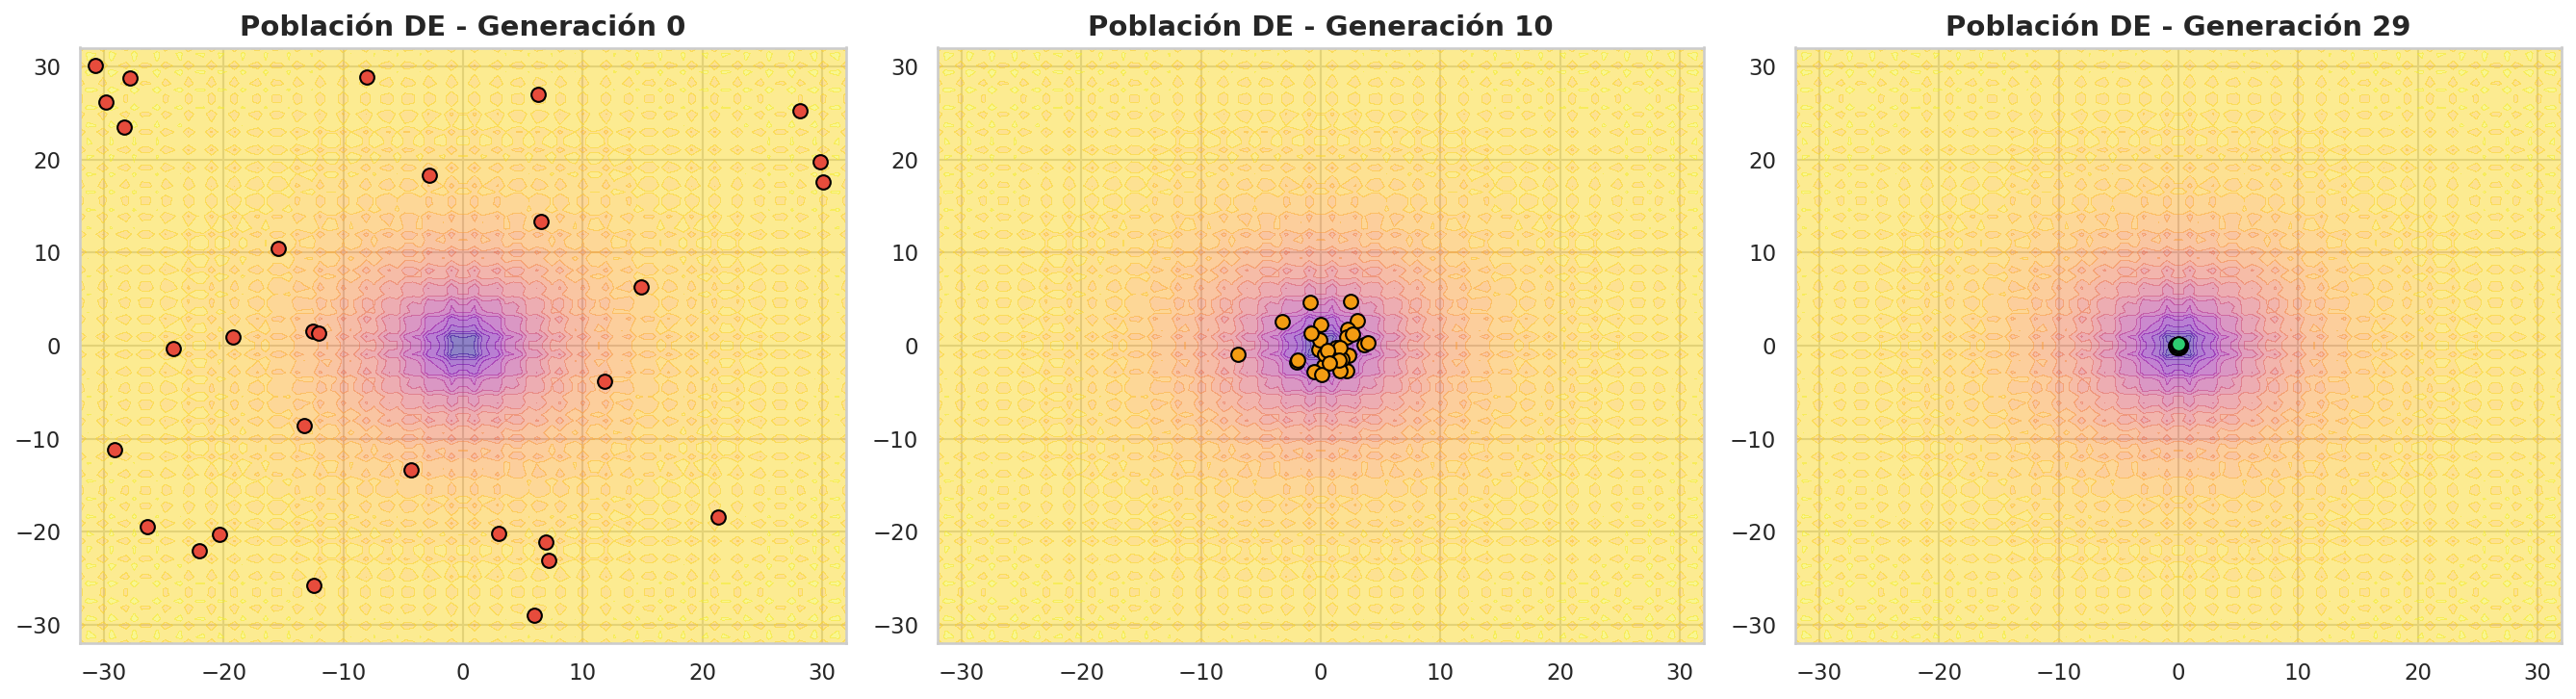

In [5]:
def de_2d_history(F=0.8, CR=0.9, N=30, G=30):
    pop = np.random.uniform(-32, 32, (N, 2))
    historia = [pop.copy()]

    def ackley_2d(x, y):
        term1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
        term2 = -np.exp(0.5 * (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
        return term1 + term2 + 20 + np.e

    for gen in range(G):
        next_pop = np.zeros_like(pop)
        fit = np.array([ackley_2d(ind[0], ind[1]) for ind in pop])

        for i in range(N):
            candidatos = list(range(N)); candidatos.remove(i)
            r1, r2, r3 = random.sample(candidatos, 3)

            v_mutante = pop[r1] + F * (pop[r2] - pop[r3])
            v_mutante = np.clip(v_mutante, -32, 32)

            u_trial = np.copy(pop[i])
            j_rand = random.randint(0, 1)
            for j in range(2):
                if random.random() < CR or j == j_rand:
                    u_trial[j] = v_mutante[j]

            if ackley_2d(u_trial[0], u_trial[1]) <= fit[i]:
                next_pop[i] = u_trial
            else:
                next_pop[i] = pop[i]
        pop = next_pop
        historia.append(pop.copy())
    return historia

hist_pop_de = de_2d_history()

# Visualización sobre el contorno de Ackley
x_a = np.linspace(-32, 32, 100); y_a = np.linspace(-32, 32, 100)
X_a, Y_a = np.meshgrid(x_a, y_a)
Z_a = -20 * np.exp(-0.2 * np.sqrt(0.5 * (X_a**2 + Y_a**2))) - np.exp(0.5 * (np.cos(2*np.pi*X_a) + np.cos(2*np.pi*Y_a))) + 20 + np.e

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
generaciones_plot = [0, 10, 29]
colores = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, gen, color in zip(axes, generaciones_plot, colores):
    ax.contourf(X_a, Y_a, Z_a, levels=20, cmap='plasma', alpha=0.5)
    pob_actual = hist_pop_de[gen]
    ax.scatter(pob_actual[:, 0], pob_actual[:, 1], c=color, edgecolor='black', s=50)
    ax.set_title(f"Población DE - Generación {gen}")
    ax.set_xlim(-32, 32); ax.set_ylim(-32, 32)

plt.tight_layout()
plt.show()


*Nota de Ingeniería:* Observar la Generación 0 (dispersión total). En la Generación 10, la población ya identificó el "embudo" central. En la Generación 29, la población está tan concentrada que los vectores de diferencia $(x_{r2} - x_{r3})$ son minúsculos, lo que genera una mutación de ajuste fino automático.

Es decir, observamos cómo la población se contrae automáticamente a medida que las diferencias $(x_{r2} - x_{r3})$ se hacen más pequeñas.

## Parte III: Análisis de Sensibilidad (Configurar DE)



Configurar DE es un arte, pero la ingeniería requiere números. Vamos a realizar un **Grid Search** sobre $F$ y $CR$ y visualizarlo en un Mapa de Calor para la función de Ackley 10D.



Calculando Grid Search para DE... (tomará unos segundos)


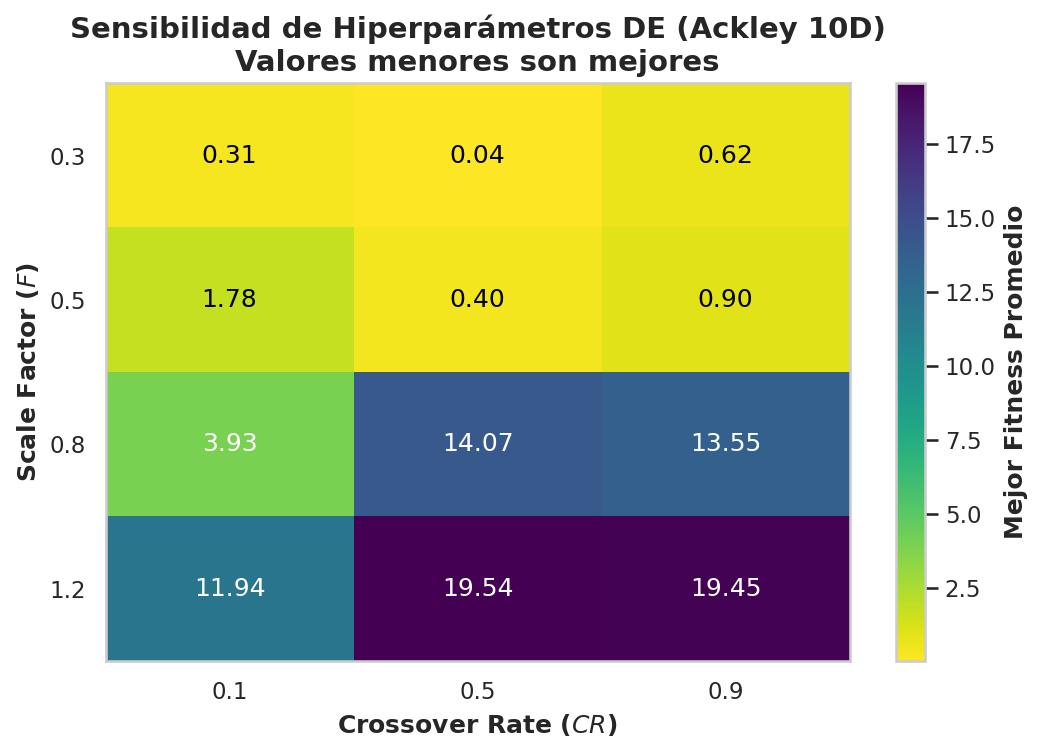

In [6]:
# Bucle manual de DE para el experimento
def de_rand_1_bin(F, CR, N=50, G=100):
    pop = np.random.uniform(-32, 32, (N, 10))
    for gen in range(G):
        next_pop = np.zeros_like(pop)
        fit = np.array([ackley_10d(ind)[0] for ind in pop])
        for i in range(N):
            candidatos = list(range(N)); candidatos.remove(i)
            r1, r2, r3 = random.sample(candidatos, 3)
            v_mutante = np.clip(pop[r1] + F * (pop[r2] - pop[r3]), -32, 32)
            u_trial = np.copy(pop[i])
            j_rand = random.randint(0, 9)
            for j in range(10):
                if random.random() < CR or j == j_rand:
                    u_trial[j] = v_mutante[j]
            if ackley_10d(u_trial)[0] <= fit[i]:
                next_pop[i] = u_trial
            else:
                next_pop[i] = pop[i]
        pop = next_pop
    return np.min([ackley_10d(ind)[0] for ind in pop])

valores_F = [0.3, 0.5, 0.8, 1.2]
valores_CR = [0.1, 0.5, 0.9]
resultados_de = np.zeros((len(valores_F), len(valores_CR)))

print("Calculando Grid Search para DE... (tomará unos segundos)")
for i, F_val in enumerate(valores_F):
    for j, CR_val in enumerate(valores_CR):
        resultados_de[i, j] = np.mean([de_rand_1_bin(F=F_val, CR=CR_val) for _ in range(2)])

# Visualización del Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
cax = ax.imshow(resultados_de, cmap='viridis_r', aspect='auto')

for i in range(len(valores_F)):
    for j in range(len(valores_CR)):
        ax.text(j, i, f"{resultados_de[i, j]:.2f}", ha="center", va="center",
                color="white" if resultados_de[i,j] > np.median(resultados_de) else "black")

ax.set_xticks(np.arange(len(valores_CR)))
ax.set_yticks(np.arange(len(valores_F)))
ax.set_xticklabels(valores_CR)
ax.set_yticklabels(valores_F)
ax.set_xlabel("Crossover Rate ($CR$)")
ax.set_ylabel("Scale Factor ($F$)")
ax.set_title("Sensibilidad de Hiperparámetros DE (Ackley 10D)\nValores menores son mejores")
fig.colorbar(cax, label="Mejor Fitness Promedio")
plt.grid(False)
plt.show()

### Criterio de Ingeniería: Interpretando el Heatmap


*   **$F$ alto (0,8 o 1,2):** Los peores resultados. La función de Ackley tiene un "embudo" muy estrecho en el centro. Si $F$ es alto, la perturbación es tan violenta que los individuos "saltan por encima" del embudo sin lograr caer en él.
*   **El "Sweet Spot" para Ackley:** Los mejores resultados se dan con **$F=0,3$ y $CR=0,5$**. Un $F$ bajo genera pasos cortos, permitiendo una explotación fina, ideal para escurrirse hacia el fondo del agujero de Ackley.

> **Lección de Ingeniería:** La literatura sugiere $F=0,8$ y $CR=0,9$ como estándar global, pero la topología del problema siempre manda. Si el óptimo es un pozo estrecho, necesitamos si o si reducir $F$ para permitir la explotación.



## Parte IV: El Gran Benchmark y la Trampa de la Convergencia Rápida



La prueba de fuego. Vamos a poner a competir a nuestro GA clásico, a la $(\mu+\lambda)$-ES y a la Evolución Diferencial en un problema de **alta dimensionalidad (20D)**.

Usamos la **Función de Rosenbrock**. A diferencia de otras funciones, Rosenbrock tiene una altísima **Epistasis** (las variables interactúan fuertemente entre sí, formando un valle curvo y estrecho).

Les damos a los tres un presupuesto computacional corto (Población = 100, Generaciones = 300). Además, monitoreamos la métrica más importante en ingeniería evolutiva: la **Diversidad** (Desviación estándar del fitness).

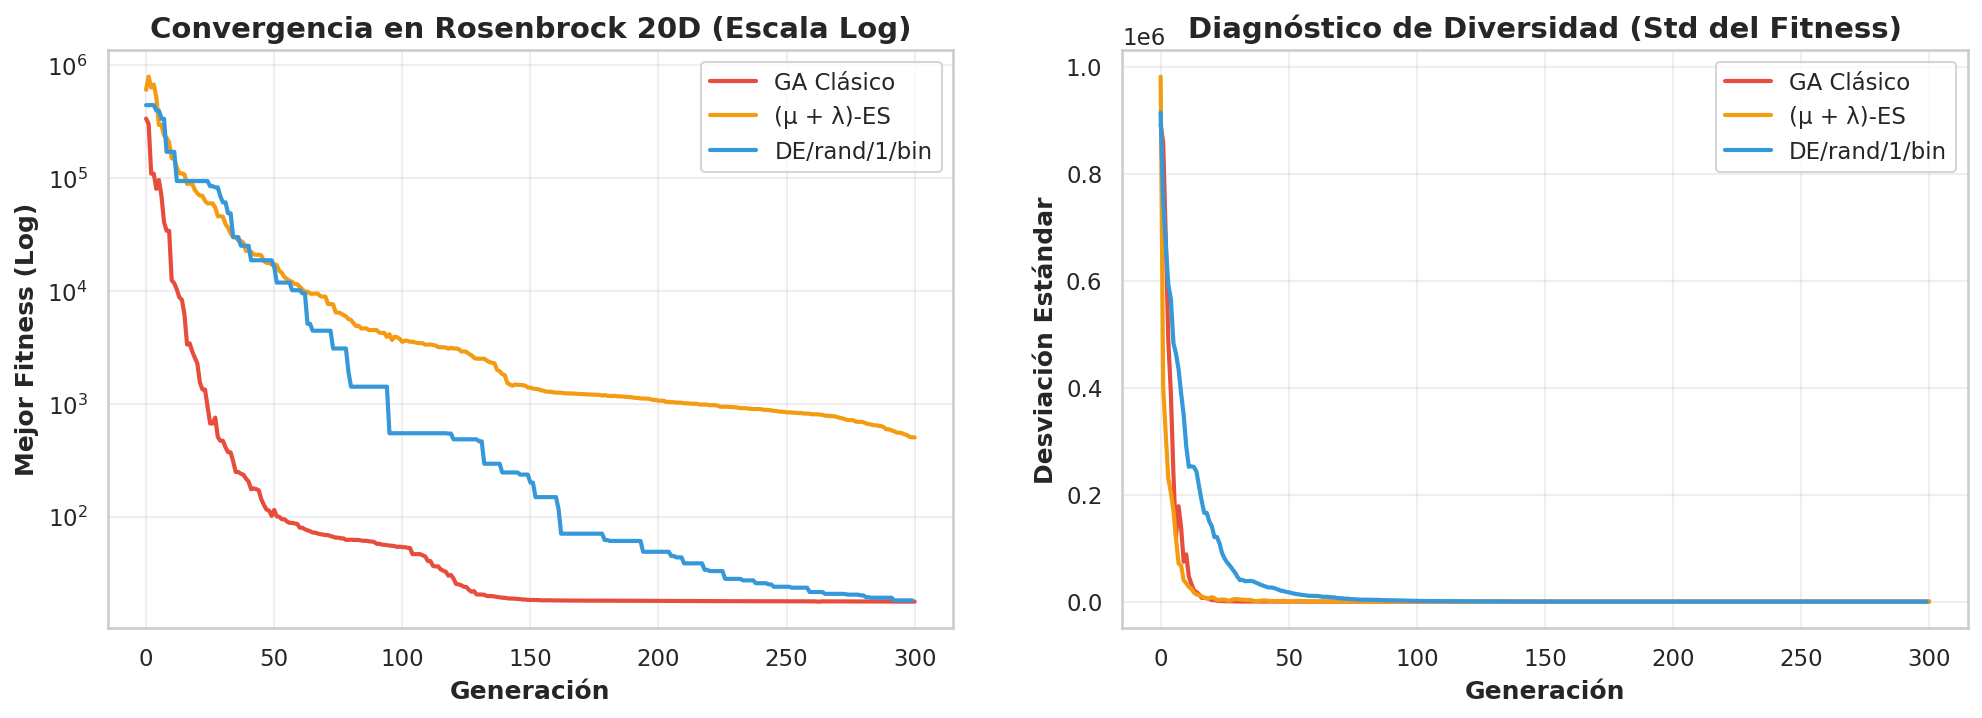

In [7]:
# Función Rosenbrock 20D
DIMENSIONES_BENCH = 20
BOUND_LOW_R, BOUND_UP_R = -5.0, 10.0

def rosenbrock_nd(ind):
    x = np.array(ind[:DIMENSIONES_BENCH])
    xi = x[:-1]
    xi1 = x[1:]
    return (np.sum(100 * (xi1 - xi**2)**2 + (1 - xi)**2),)

# 1. Ejecutamos GA Clásico
def ga_clasico_rosenbrock(N=100, G=300):
    tb_ga = base.Toolbox()
    tb_ga.register("attr_float", random.uniform, BOUND_LOW_R, BOUND_UP_R)
    tb_ga.register("individual", tools.initRepeat, creator.Individual, tb_ga.attr_float, n=DIMENSIONES_BENCH)
    tb_ga.register("population", tools.initRepeat, list, tb_ga.individual)

    tb_ga.register("evaluate", rosenbrock_nd)
    tb_ga.register("mate", tools.cxBlend, alpha=0.5)
    tb_ga.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.1)
    tb_ga.register("select", tools.selTournament, tournsize=3)

    def limitar_dominio_r(func):
        def wrapper(*args, **kwargs):
            resultados = func(*args, **kwargs)
            for ind in resultados:
                for i in range(len(ind)):
                    ind[i] = max(BOUND_LOW_R, min(BOUND_UP_R, ind[i]))
            return resultados
        return wrapper

    tb_ga.decorate("mate", limitar_dominio_r)
    tb_ga.decorate("mutate", limitar_dominio_r)

    pop = tb_ga.population(n=N)
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("min", np.min)
    stats.register("std", np.std)
    pop, log = algorithms.eaSimple(pop, tb_ga, cxpb=0.8, mutpb=0.2, ngen=G, stats=stats, verbose=False)
    return log.select("min"), log.select("std")

# 2. Ejecutamos ES
def generar_individuo_es_rosenbrock():
    x = [random.uniform(BOUND_LOW_R, BOUND_UP_R) for _ in range(DIMENSIONES_BENCH)]
    sigmas = [random.uniform(0.1, 1.0) for _ in range(DIMENSIONES_BENCH)]
    return creator.Individual(x + sigmas)

def mutacion_autoadaptativa_rosenbrock(individuo):
    tau = 1.0 / np.sqrt(2.0 * DIMENSIONES_BENCH)
    tau_prime = 1.0 / np.sqrt(2.0 * np.sqrt(DIMENSIONES_BENCH))
    ruido_global = random.gauss(0, 1)
    for i in range(DIMENSIONES_BENCH):
        individuo[DIMENSIONES_BENCH + i] *= np.exp(tau_prime * ruido_global + tau * random.gauss(0, 1))
        individuo[DIMENSIONES_BENCH + i] = max(individuo[DIMENSIONES_BENCH + i], 1e-5)
        individuo[i] += random.gauss(0, individuo[DIMENSIONES_BENCH + i])
        individuo[i] = max(BOUND_LOW_R, min(BOUND_UP_R, individuo[i]))
    return individuo,

def es_rosenbrock(N=100, G=300):
    tb_es_r = base.Toolbox()
    tb_es_r.register("individual", generar_individuo_es_rosenbrock)
    tb_es_r.register("population", tools.initRepeat, list, tb_es_r.individual)
    tb_es_r.register("evaluate", rosenbrock_nd)
    tb_es_r.register("mutate", mutacion_autoadaptativa_rosenbrock)
    tb_es_r.register("mate", tools.cxTwoPoint)
    tb_es_r.register("select", tools.selTournament, tournsize=3)

    pop_es = tb_es_r.population(n=N)
    stats_es = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats_es.register("min", np.min)
    stats_es.register("std", np.std)

    _, log_es = algorithms.eaMuPlusLambda(pop_es, tb_es_r, mu=int(N/4), lambda_=N, cxpb=0.6, mutpb=0.3, ngen=G, stats=stats_es, verbose=False)
    return log_es.select("min"), log_es.select("std")

# 3. Ejecutamos DE
def de_rand_1_bin_rosenbrock(F=0.5, CR=0.9, N=100, G=300):
    pop = np.random.uniform(BOUND_LOW_R, BOUND_UP_R, (N, DIMENSIONES_BENCH))
    hist_min, hist_std = [], []
    for gen in range(G):
        next_pop = np.zeros_like(pop)
        fit = np.array([rosenbrock_nd(ind)[0] for ind in pop])
        hist_min.append(fit.min())
        hist_std.append(fit.std())

        for i in range(N):
            candidatos = list(range(N)); candidatos.remove(i)
            r1, r2, r3 = random.sample(candidatos, 3)

            # Mutación Diferencial
            v_mutante = pop[r1] + F * (pop[r2] - pop[r3])

            # Cruce Binomial
            u_trial = np.copy(pop[i])
            j_rand = random.randint(0, DIMENSIONES_BENCH - 1)
            for j in range(DIMENSIONES_BENCH):
                if random.random() < CR or j == j_rand:
                    u_trial[j] = v_mutante[j]

            # Clipping post-cruce
            u_trial = np.clip(u_trial, BOUND_LOW_R, BOUND_UP_R)

            if rosenbrock_nd(u_trial)[0] <= fit[i]:
                next_pop[i] = u_trial
            else:
                next_pop[i] = pop[i]
        pop = next_pop
    return hist_min, hist_std

# Ejecución del Benchmark
N_POB = 100
N_GEN = 300
hist_ga_min, hist_ga_std = ga_clasico_rosenbrock(N=N_POB, G=N_GEN)
hist_es_min, hist_es_std = es_rosenbrock(N=N_POB, G=N_GEN)
# Usamos F=0.5 porque Rosenbrock es un valle estrecho (como vimos en el heatmap de Ackley)
hist_de_min, hist_de_std = de_rand_1_bin_rosenbrock(F=0.5, CR=0.9, N=N_POB, G=N_GEN)

# Visualización del Benchmark
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Usamos escala logarítmica porque Rosenbrock tiene valores iniciales inmensos
ax1.semilogy(hist_ga_min, label='GA Clásico', color='#e74c3c', lw=2)
ax1.semilogy(hist_es_min, label='(μ + λ)-ES', color='#f39c12', lw=2)
ax1.semilogy(hist_de_min, label='DE/rand/1/bin', color='#3498db', lw=2)
ax1.set_title("Convergencia en Rosenbrock 20D (Escala Log)")
ax1.set_xlabel("Generación"); ax1.set_ylabel("Mejor Fitness (Log)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(hist_ga_std, label='GA Clásico', color='#e74c3c', lw=2)
ax2.plot(hist_es_std, label='(μ + λ)-ES', color='#f39c12', lw=2)
ax2.plot(hist_de_std, label='DE/rand/1/bin', color='#3498db', lw=2)
ax2.set_title("Diagnóstico de Diversidad (Std del Fitness)")
ax2.set_xlabel("Generación"); ax2.set_ylabel("Desviación Estándar")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.show()

**Discusión de Resultados**:  
Si le mostramos la gráfica de la izquierda a un principiante en la generación 50, diría: *"El GA Clásico (rojo) es el mejor algoritmo, bajó rapidísimo"*.

Como ingenieros, debemos mirar la gráfica de la derecha (Diversidad) para descubrir la verdad: **El GA Clásico es un velocista que acaba de sufrir un infarto.**

1. **El GA Clásico (Rojo):** Baja como una piedra en las primeras 50 generaciones, pero su diversidad colapsa a cero casi inmediatamente. El GA sufrió de **Convergencia Prematura**. Se quedó atascado en un fitness de $\approx 10^2$ (el óptimo es $0$). Al perder toda su diversidad, todos los individuos son clones; el algoritmo está clínicamente muerto y jamás encontrará la solución real. ¿Por qué? Porque el cruce aritmético promedia a los padres. Si se promedian dos puntos que están dentro de un valle curvo, el punto resultante caerá *fuera* del valle. El GA destruye sus propias soluciones.
2. **Estrategias Evolutivas (Amarillo):** Logra un buen balance. Desciende más lento pero mantiene la diversidad por más tiempo gracias a la autoadaptación de sus sigmas.
3. **Evolución Diferencial (Azul):** Parece el perdedor porque baja muy lento. Pero, mirar su diversidad. Se mantiene alta y desciende de forma suave y controlada. DE es un **corredor de maratón**. Si le diéramos más generaciones, DE encontraría el $0$ exacto, mientras que el GA seguiría atascado en $10^2$ para toda la eternidad.


### Ahora con `1.000` Generaciones

Vemos qué pasa efectivamente con los algoritmos si obtienen más presupuesto computacional:

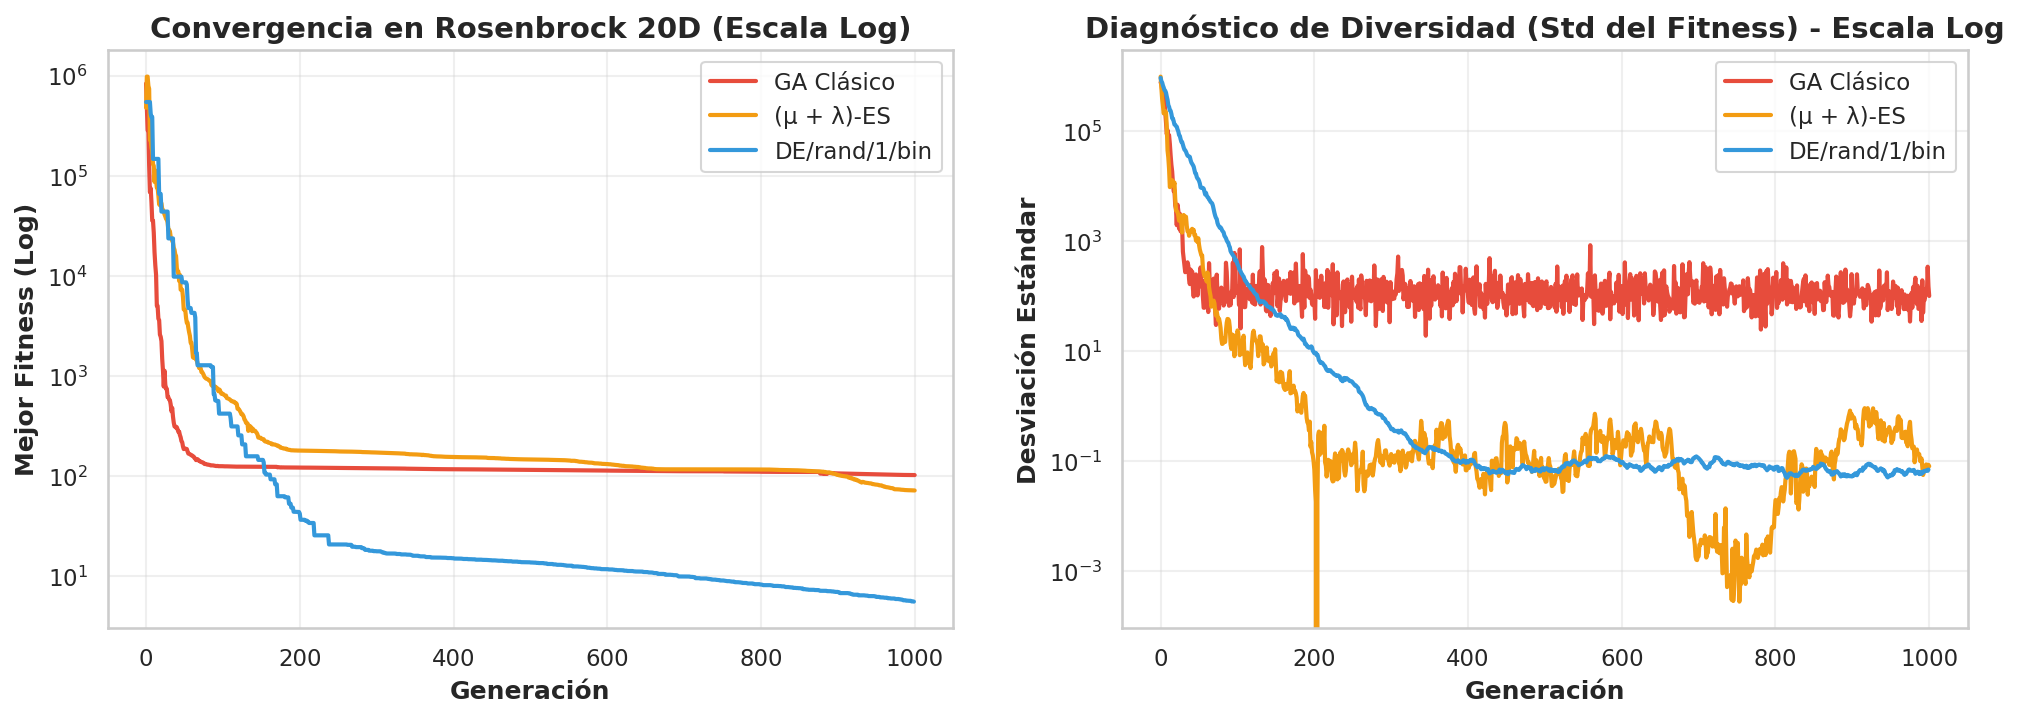

In [9]:
# Ejecución del Benchmark
N_POB = 100
              # Extendemos el horizonte para ver el comportamiento asintótico
N_GEN = 1000  # <--- 1000 generaciones ahora, único cambio
hist_ga_min, hist_ga_std = ga_clasico_rosenbrock(N=N_POB, G=N_GEN)
hist_es_min, hist_es_std = es_rosenbrock(N=N_POB, G=N_GEN)
# Usamos F=0.5 porque Rosenbrock es un valle estrecho (como vimos en el heatmap de Ackley)
hist_de_min, hist_de_std = de_rand_1_bin_rosenbrock(F=0.5, CR=0.9, N=N_POB, G=N_GEN)


# Visualización del Benchmark
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Usamos escala logarítmica porque Rosenbrock tiene valores iniciales inmensos
ax1.semilogy(hist_ga_min, label='GA Clásico', color='#e74c3c', lw=2)
ax1.semilogy(hist_es_min, label='(μ + λ)-ES', color='#f39c12', lw=2)
ax1.semilogy(hist_de_min, label='DE/rand/1/bin', color='#3498db', lw=2)
ax1.set_title("Convergencia en Rosenbrock 20D (Escala Log)")
ax1.set_xlabel("Generación"); ax1.set_ylabel("Mejor Fitness (Log)")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Eje logarítmico también para ver comportamiento en valores pequeños
ax2.semilogy(hist_ga_std, label='GA Clásico', color='#e74c3c', lw=2)
ax2.semilogy(hist_es_std, label='(μ + λ)-ES', color='#f39c12', lw=2)
ax2.semilogy(hist_de_std, label='DE/rand/1/bin', color='#3498db', lw=2)
ax2.set_title("Diagnóstico de Diversidad (Std del Fitness) - Escala Log")
ax2.set_xlabel("Generación"); ax2.set_ylabel("Desviación Estándar")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.show()

Extendimos el horizonte a 1000 generaciones y cambiamos la escala de diversidad a logarítmica para hacer un diagnóstico real.

1. **El GA Clásico (Rojo):** Mirar su gráfica de diversidad: choca contra un "piso" constante. ¿Qué es ese piso? Es el ruido inyectado por nuestra mutación gaussiana fija ($\sigma=0.5$). La población ya no está explorando el valle de Rosenbrock; simplemente está "vibrando" en el lugar, atrapada contra una pared curva que su cruce aritmético no le permite navegar. Por eso decíamos que está clínicamente muerto.
2. **Estrategias Evolutivas (Amarillo):** Logra superar al GA a largo plazo, pero mirar su diversidad: es tremendamente errática. El algoritmo está intentando adaptar 20 tamaños de paso ($\sigma$) independientes. Pero en Rosenbrock, las variables están fuertemente entrelazadas (epistasis). Al no tener una matriz de covarianza que entienda las diagonales, la ES da pasos a ciegas, rebotando por las paredes del valle.
3. **Evolución Diferencial (Azul):** Parece el perdedor al inicio, pero es el único que resuelve el problema. Observar su curva de diversidad: es una caída monótona, suave y perfecta. ¿Por qué? Porque DE usa la diferencia entre individuos $(x_{r2} - x_{r3})$. A medida que la población se adentra en el estrecho valle de Rosenbrock, los individuos se acercan entre sí. Automáticamente, los vectores de diferencia se encogen, reduciendo el tamaño de paso sin necesidad de ningún $\sigma$ externo. DE se "escurre" por la curva del valle de forma natural y sostenida.


> **Conclusión Final:** En optimización continua compleja, desconfiar de las caídas verticales rápidas. Suelen ser síntoma de que el algoritmo fue absorbido por un óptimo local masivo. Algoritmos como **DE** sacrifican velocidad inicial a cambio de una exploración robusta que garantiza encontrar el óptimo global a largo plazo.

## Síntesis: ¿Qué algoritmo elegir?



Nuevamente, queda casi que demostrado que no existe "el mejor algoritmo". Existe el algoritmo más adecuado para el paisaje del problema. Adjunto una tabla comparativa que resume lo abordado hasta este punto, de modo de guiar las decisiones de diseño:

| Característica | Algoritmo Genético (GA) | Estrategias Evolutivas (ES) | Evolución Diferencial (DE) |
| :--- | :--- | :--- | :--- |
| **Representación** | Binaria, Entera, Real, Permutaciones | Estrictamente Real (Continua) | Estrictamente Real (Continua) |
| **Mecanismo de Exploración** | Cruce y Mutación ciega ($\sigma$ fijo) | Mutación Autoadaptativa ($\sigma$ evoluciona) | Diferencia vectorial poblacional |
| **Hiperparámetros** | Muchos ($N, p_c, p_m, \sigma$, torneo) | Medios ($\mu, \lambda$, tasas de aprendizaje) | Pocos ($N, F, CR$) |
| **Mantenimiento de Diversidad** | Bajo (Propenso a convergencia prematura) | Medio | **Alto** (Excelente exploración) |
| **Caso de Uso Ideal** | Problemas combinatorios, discretos o mixtos. | Problemas continuos ruidosos o dinámicos (CMA-ES). | **El estándar de facto** para optimización continua de alta dimensión. |





> **El Estado del Arte: CMA-ES (Covariance Matrix Adaptation)**  
> Lo que implementamos aquí en ES adapta un $\sigma$ independiente para cada variable (varianza). Pero, ¿qué pasa si las variables están correlacionadas (como en Rosenbrock)?   
> El algoritmo **CMA-ES** da un paso más allá: evoluciona una **matriz de covarianza completa**, permitiendo que la mutación se adapte a la forma exacta del paisaje. Hoy en día, CMA-ES es considerado el algoritmo de caja negra *estado del arte* para optimización continua. DEAP incluye una implementación nativa en `deap.cma`.

## Conexiones y Próximos Pasos



Hasta este punto, tenemos lo necesario para dominar los espacios continuos. Sabemos que si el problema tiene muchas variables correlacionadas, **DE** es nuestro mejor aliado. Si el problema es ruidoso, una **ES** tipo "coma" nos salvará.

Pero, ¿qué pasa si en lugar de basarnos en la genética y la evolución, nos basamos en la psicología social y el comportamiento de una bandada de pájaros buscando comida?

En el próximo notebook, exploramos el mundo de la **Inteligencia Colectiva**.

- ➡️ **Siguiente:** [Inteligencia Colectiva: Enjambres de Partículas (PSO) y Colonias de Hormigas (ACO)](06_inteligencia_enjambres_pso.ipynb)
- 🔄 **Relacionado:** [Optimización Combinatoria: Espacios Discretos y Permutaciones](04_optimizacion_combinatoria.ipynb)



## Referencias


### Artículos Fundacionales

1. **Storn, R., & Price, K. (1997)**. *Differential Evolution – A Simple and Efficient Heuristic for Global Optimization over Continuous Spaces*. Journal of Global Optimization.    
   (**Paper original de DE**).

2. **Beyer, H.-G., & Schwefel, H.-P. (2002)**. *Evolution Strategies – A Comprehensive Introduction*. Natural Computing.  
   (Referencia estándar para ES y autoadaptación).

3. **Hansen, N., & Ostermeier, A. (2001)**. *Completely Derandomized Self-Adaptation in Evolution Strategies*. Evolutionary Computation.  
   (CMA-ES — el estado del arte moderno en Estrategias Evolutivas).


### Recursos Prácticos

- **DEAP Documentation** — Ejemplo oficial de [CMA-ES](https://deap.readthedocs.io/en/master/examples/cmaes.html).

---


## Entorno de Ejecución


In [9]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
